# Optimering av batterilagerdispatch för energiarbitrage och topputjämning


## Sammanfattning

En nätansluten kommersiell anläggning driver ett litiumjonbatteri på 2 MW / 8 MWh vid sidan av en mätarförsedd elektrisk last. Anläggningen debiteras på två sätt: ett timvis **energipris** för dagen-före-marknaden ($/MWh) och en månatlig **effektavgift** på sitt enskilt högsta nätimportintervall ($/MW). Tillgångsförvaltaren måste besluta, timme för timme, när batteriet ska laddas (köpa billig energi och höja nätuttaget) och när det ska laddas ur (kompensera dyr energi och sänka nätuttaget). Två värdeströmmar konkurrerar: **energiarbitrage** (köp lågt över natten, ladda ur vid kvällstoppen) och **topputjämning** (begränsa det debiterade nätmaximumet). Att ladda är inte gratis — rundtursverkningsgraden innebär att ungefär 10 % av den lagrade energin går förlorad — så schemat är en genuin optimering, inte en heuristik.

Den här notebooken bygger beslutet från början till slut. Först syntetiseras en realistisk 24-timmars priskurva för dagen-före-marknaden (med morgon- och kvällstoppar plus en dal under natten) och en korrelerad lastprofil för anläggningen, som sedan profileras med **PROC MEANS** och ett robust 2,5/97,5-percentils prisband via **PROC UNIVARIATE**. Kärnan är ett linjärt program i **PROC OPTMODEL**: beslutsvariabler för timvis laddning, urladdning och laddningsnivå, plus en variabel för debiterad topp, underställt en kumulativ balans för laddningsnivån (med separat verkningsgrad för laddning/urladdning), effekt- och kapacitetsgränser samt en toppdefinitionsvillkor. Målfunktionen maximerar arbitragemarginalen netto efter effektavgiften. **PROC SQL** kvantifierar sedan kostnaden för baslinje kontra optimerat, och tre **PROC SGPLOT**-paneler visualiserar laddnings-/urladdningsschemat mot priset, laddningsnivåns bana och den utjämnade nätimportprofilen.

**Resultat på den syntetiska dagen:** optimeraren fyller batteriet under de billigaste nattimmarna, laddar ur in i både morgon- och kvällsprisertopparna, laddar om genom prisdalen mitt på dagen och — avgörande — håller tillbaka sin laddningseffekt så att den aldrig skapar en ny nättopp. Den dagliga energikostnaden faller från **\$2 903,78 till \$2 528,43** — **\$375,34 (12,9 %) i arbitragebesparingar** — samtidigt som det debiterade nätmaximumet sjunker från **3,59 MW till 3,43 MW** (cirka **0,16 MW**), värt ytterligare **\$18,98** vid den antagna effektavgiften per dagsandel. Samma modell skalar till längre horisonter, flera prisscenarier eller degraderingsmedveten cykling helt enkelt genom att utöka indexmängden och villkoren.

## Datakällor

All data är **syntetisk**, genererad inline i den första kodcellen med `CALL STREAMINIT(20260605)` för reproducerbarhet. Inga externa filer eller nätverksåtkomst. En dataset, `price_load`, med 24 timrader som representerar en enda driftdag.

| Variabel | Typ | Enheter | Beskrivning |
|----------|------|-------|-------------|
| `hour` | num | 0–23 | Timme på driftdagen (horisontindex) |
| `price` | num | $/MWh | Energipris för dagen-före-marknaden: dal under natten, morgon- + kvällstoppar, med gaussiskt brus (golvat vid $5) |
| `load` | num | MW | Anläggningens elektriska efterfrågan, korrelerad med daglig aktivitet (golvat vid 0,3 MW) |
| `day_type` | char | — | Flagga för tariffönster: `PeakTOU` (timmarna 17–21) mot `OffPeak`, används för sammanfattningen av pris-spreaden topp/lågtrafik |

Batteriparametrarna är fasta modellkonstanter inuti PROC OPTMODEL: 8 MWh användbar kapacitet, 2 MW max laddnings-/urladdningseffekt, 0,95 verkningsgrad för laddning och 0,95 för urladdning (~90 % rundtur), initial laddningsnivå 0 MWh, och en effektavgift på \$120/MW som tillämpas på dagens debiterade nättopp (den dagligt amorterade andelen av en månatlig effektavgift).

# Optimering av batterilagerdispatch
## Energiarbitrage och topputjämning för en nätansluten anläggning

En kommersiell anläggning driver ett **2 MW / 8 MWh-batteri** bakom sin mätare. Elräkningen har två delar: ett timvis **energipris** ($/MWh) och en månatlig **effektavgift** på det enskilt högsta nätimportintervallet ($/MW). Operatören vill ha ett timvis laddnings-/urladdningsschema som fångar två värdeströmmar samtidigt:

- **Arbitrage** — lagra billig nattenergi, släpp ut den under dyra topptimmar.
- **Topputjämning** — ladda ur under efterfrågespiken för att sänka det debiterade nätmaximumet.

Eftersom rundtursverkningsgraden förlorar ~10 % av den lagrade energin är avvägningen inte trivial och motiverar en verklig optimering. Vi formulerar den som ett linjärt program i **PROC OPTMODEL**, och kvantifierar och visualiserar sedan resultatet.

> All data nedan är syntetisk och genererad inline — notebooken är helt fristående och körs på några sekunder.

## 1. Generera en syntetisk pris- och lastprofil för dagen-före-marknaden

Vi bygger en driftdag (24 timrader). Priskurvan har en dal under natten och morgon- + kvällstoppar; anläggningens last är korrelerad med daglig aktivitet. Ett fast frö håller körningen reproducerbar. Vi taggar också det lagstadgade tidsberoende toppfönstret så att vi kan sammanfatta spreaden topp/lågtrafik senare.

In [1]:
data price_load;
    CALL streaminit(20260605);
    LÄNGD day_type $16;
    GÖR hour = 0 TILL 23;
        /* Dygnsvariation i energipris ($/MWh): morgon- + kvällstoppar */
        BASE = 38
             + 26 * EXP(-((hour - 8)**2) / 6)
             + 40 * EXP(-((hour - 19)**2) / 5)
             - 14 * EXP(-((hour - 3)**2) / 8);
        price = round(BASE + rand('normal', 0, 4), 0.01);
        OM price < 5 SÅ price = 5;

        /* Anläggningslast (MW): dal under natten, kvällsuppgång */
        LOAD = round(2.0
             + 1.6 * EXP(-((hour - 19)**2) / 7)
             + 0.7 * EXP(-((hour - 9)**2) / 10)
             + rand('normal', 0, 0.10), 0.01);
        OM LOAD < 0.3 SÅ LOAD = 0.3;

        OM hour >= 17 AND hour <= 21 SÅ day_type = 'Topptid';
        ANNARS day_type = 'Lågtrafik';
        UTDATA;
    SLUT;
    TA_BORT BASE;
KÖR;


NOTE: DATA price_load


NOTE: Wrote price_load (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. Profilera pris- och lastfördelningarna

Innan vi optimerar gör vi en rimlighetskontroll av indata. Spreaden mellan de billigaste och dyraste timmarna är det som arbitrage monetariserar, och maximal last förankrar möjligheten till topputjämning.

In [2]:
PROCEDUR MEDELVÄRDEN data=price_load n mean std MIN MAX maxdec=2;
    VARIABEL price LOAD;
    ETIKETT price="Pris ($/MWh)" LOAD="Last (MW)";
KÖR;

                                                  The MEANS Procedure

 Variable  Label               N        Mean     Std Dev     Minimum     Maximum
 -------------------------------------------------------------------------------
 price     Pris ($/MWh)       24       46.29       15.81       18.57       79.27
 LOAD      Last (MW)          24        2.47        0.48        1.71        3.59
 -------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Pris-spread topp mot lågtrafik

Att gruppera efter den tidsberoende flaggan visar hur mycket rikare topptimmarna är än lågtrafikbaslinjen — den strukturella signalen som batteriet utnyttjar.

In [3]:
PROCEDUR MEDELVÄRDEN data=price_load mean MIN MAX maxdec=2;
    KLASS day_type;
    VARIABEL price;
    ETIKETT price="Pris ($/MWh)" day_type="Tariffönster";
KÖR;

                                                  The MEANS Procedure

                                        Analysis Variable : price Pris ($/MWh)

                                                  N
                               Tariffönster     Obs       Mean      Minimum      Maximum
                               ---------------------------------------------------------
                               Lågtrafik         19      40.46        18.57        54.89
                               Topptid            5      68.45        54.88        79.27
                               ---------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Robust prisband (2,5 / 97,5-percentiler)

Vi karakteriserar prissvansarna med ett 2,5 / 97,5-percentils band. **PROC UNIVARIATE** med `PCTLPTS=` beräknar godtyckliga percentiler rent, vilket är rätt verktyg för fraktionella percentiler.

In [4]:
PROCEDUR UNIVARIATE data=price_load NOPRINT;
    VARIABEL price;
    UTDATA out=price_band pctlpts=2.5 97.5 pctlpre=p_;
KÖR;

PROCEDUR SKRIV data=price_band noobs ETIKETT;
    ETIKETT p_2_5="Pris P2,5 ($/MWh)" p_97_5="Pris P97,5 ($/MWh)";
KÖR;


Pris P2,5 ($/MWh)  Pris P97,5 ($/MWh)
-----------------  ------------------
            18.57               79.27




NOTE: PROC UNIVARIATE
NOTE: Output dataset price_band has 1 observations and 2 variables.
NOTE: PROC PRINT data=price_band

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## 5. Dispatchoptimeringen (linjärt program)

Vi läser in det timvisa priset och lasten i PROC OPTMODEL och deklarerar:

- `chg[h]`, `dis[h]` — timvis laddnings- / urladdningseffekt (MW), begränsad av växelriktarens märkeffekt på 2 MW.
- `soc[h]` — laddningsnivå (MWh), begränsad av den användbara kapaciteten på 8 MWh.
- `peak` — det debiterade nätmaximumet (MW).

**Villkor.** `soc_balance` ackumulerar nettoenergi genom varje timme med separat verkningsgrad för laddning/urladdning (en löpande-summa-form av den timvisa rekursionen). `peak_def` tvingar `peak` att dominera varje timmes nettonätimport, så att minimering av den utjämnar effektavgiften.

**Målfunktion.** Maximera arbitragemarginalen — `price × (discharge − charge)` summerat över dagen — minus effektavgiften på den debiterade toppen. Vi löser det som ett kontinuerligt LP.

In [5]:
PROCEDUR optmodel;
    STÄLL_IN HOURS;
    num price{HOURS};
    num LOAD{HOURS};

    READ data price_load INTO HOURS=[hour]
        price=price col=price
        LOAD=LOAD col=LOAD;

    /* Battery: 8 MWh usable, 2 MW power, ~90% round-trip efficiency */
    num capacity   = 8.0;
    num p_max      = 2.0;
    num eta_chg    = 0.95;
    num eta_dis    = 0.95;
    num soc0       = 0.0;
    num dt         = 1.0;
    /* Demand charge applied to this day's billed grid peak ($/MW).
       Commercial demand charges are monthly; 120 is the marginal value of
       shaving today's grid maximum once the monthly charge is amortized to
       the day. It is large enough that the optimizer will hold charging
       power back rather than create a new, higher peak. */
    num demand_chg = 120;

    /* Decision variables (MW charge / discharge, MWh state of charge) */
    VARIABEL chg{HOURS}  >= 0 <= p_max;
    VARIABEL dis{HOURS}  >= 0 <= p_max;
    VARIABEL soc{HOURS}  >= 0 <= capacity;
    VARIABEL peak        >= 0;   /* billed grid peak (MW) for demand charge */

    /* Net grid import after battery action (MW) */
    impvar grid_mw{h IN HOURS} = LOAD[h] + chg[h] - dis[h];

    /* Cumulative state of charge: energy in less energy out through hour h,
       with charge/discharge efficiency applied. Equivalent to an hourly
       recurrence but stated as a running sum over prior hours. */
    con soc_balance{h IN HOURS}:
        soc[h] = soc0
                 + sum{k IN HOURS: k <= h}
                     (eta_chg * chg[k] - dis[k] / eta_dis) * dt;

    /* Peak shaving: billed peak is the max grid import across the day */
    con peak_def{h IN HOURS}: peak >= grid_mw[h];

    /* Maximize energy-arbitrage margin net of the peak demand charge */
    MAX net_value =
        sum{h IN HOURS} price[h] * (dis[h] - chg[h]) * dt
        - demand_chg * peak;

    solve WITH lp;

    CREATE data dispatch FROM [hour=HOURS]
        price=price[hour]
        LOAD=LOAD[hour]
        charge_mw=chg[hour]
        discharge_mw=dis[hour]
        soc_mwh=soc[hour]
        grid_mw=grid_mw[hour];
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Maximization
  Objective Function            NET_VALUE
  Objective Type                Linear

  Number of Variables           73
  Bounded Above                 0
  Bounded Below                 1
  Bounded Below and Above       72
  Free                          0
  Fixed                         0

  Number of Constraints         48

                          Solution Summary
  Solver                        LP
  Objective Function            NET_VALUE
  Solution Status               Optimal
  Objective Value               -36.4771665526




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## 6. Det optimala timvisa schemat

Den lösta tabellen visar laddning spridd över de billiga natt- och middagstimmarna — modererad till ungefär 1,0–1,7 MW så att den aldrig sätter en ny nättopp — urladdning koncentrerad till morgon- och kvällsprisertopparna, och laddningsnivån som spårar en förnuftig fyll-och-släpp-cykel inom taket på 8 MWh. Kolumnen `grid_mw` håller ett platt tak på ~3,43 MW genom varje laddningstimme, signaturen för det bindande toppvillkoret.

In [6]:
PROCEDUR SKRIV data=dispatch noobs ETIKETT;
    VARIABEL hour price LOAD charge_mw discharge_mw soc_mwh grid_mw;
    ETIKETT hour="Timme"
          price="Pris ($/MWh)"
          LOAD="Last (MW)"
          charge_mw="Laddning (MW)"
          discharge_mw="Urladdning (MW)"
          soc_mwh="Laddningsnivå (MWh)"
          grid_mw="Nätimport (MW)";
KÖR;


Timme  Pris ($/MWh)  Last (MW)  Laddning (MW)  Urladdning (MW)   Laddningsnivå (MWh)   Nätimport (MW)
-----  ------------  ---------  -------------  ---------------  --------------------  ---------------
    0         29.73       1.99      1.4418421                0               1.36975        3.4318421
    1         28.03       2.16      1.2718421                0                 2.578        3.4318421
    2         21.87          2      1.4318421                0               3.93825        3.4318421
    3         18.57       1.71      1.7218421                0                 5.574        3.4318421
    4         27.62       2.13      1.3018421                0               6.81075        3.4318421
    5         36.12       2.18      1.2518421                0                     8        3.4318421
    6         50.37       2.32              0                0                     8             2.32
    7         54.56       2.47              0                2             5.8947


NOTE: PROC PRINT data=dispatch

NOTE: PROC PRINT completed: 24 observations printed, 7 variables


## 7. Rubriknyckeltal: baslinje mot optimerat

Vi jämför gör-inget-baslinjen (betala priset för den råa lasten varje timme) mot den optimerade nätpositionen, och rapporterar arbitragebesparingarna, minskningen av den debiterade toppen och dollarvärdet av den minskningen vid effektavgiften — de två spakarna som driver affärsnyttan.

In [7]:
PROCEDUR SQL;
    CREATE TABLE kpi AS
    VÄLJ
        sum(price * LOAD)                        AS base_energy_cost,
        sum(price * grid_mw)                     AS opt_energy_cost,
        sum(price * LOAD) - sum(price * grid_mw) AS arbitrage_savings,
        MAX(LOAD)                                AS base_peak_mw,
        MAX(grid_mw)                             AS opt_peak_mw,
        MAX(LOAD) - MAX(grid_mw)                 AS peak_reduction_mw,
        120 * (MAX(LOAD) - MAX(grid_mw))         AS demand_charge_savings
    FROM dispatch;
QUIT;

PROCEDUR SKRIV data=kpi noobs ETIKETT;
    ETIKETT base_energy_cost="Baslinjens energikostnad ($)"
          opt_energy_cost="Optimerad energikostnad ($)"
          arbitrage_savings="Arbitragebesparing ($)"
          base_peak_mw="Baslinjens topp (MW)"
          opt_peak_mw="Optimerad topp (MW)"
          peak_reduction_mw="Toppreduktion (MW)"
          demand_charge_savings="Effektavgiftsbesparing ($)";
KÖR;

Baslinjens energikostnad ($)  Optimerad energikostnad ($)  Arbitragebesparing ($)  Baslinjens topp (MW)  Optimerad topp (MW)  Toppreduktion (MW)  Effektavgiftsbesparing ($)
----------------------------  ---------------------------  ----------------------  --------------------  -------------------  ------------------  --------------------------
                   2903.7774              2528.4335145526          375.3438854474                  3.59            3.4318421           0.1581579                   18.978948




NOTE: PROC SQL 

NOTE: Table kpi created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=kpi

NOTE: PROC PRINT completed: 1 observations printed, 7 variables


## 8. Laddnings- / urladdningsschema mot pris

Laddning (blå nålar) och urladdning (röd linje med markörer) delar den vänstra megawatt-axeln; priset för dagen-före-marknaden (grön streckad) avläses till höger. Laddning klustrar i de billiga natt- och middagstimmarna, medan urladdning avfyras in i morgon- och kvällsprisertopparna — det visuella bekräftar att optimeraren köper lågt och säljer högt.


NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


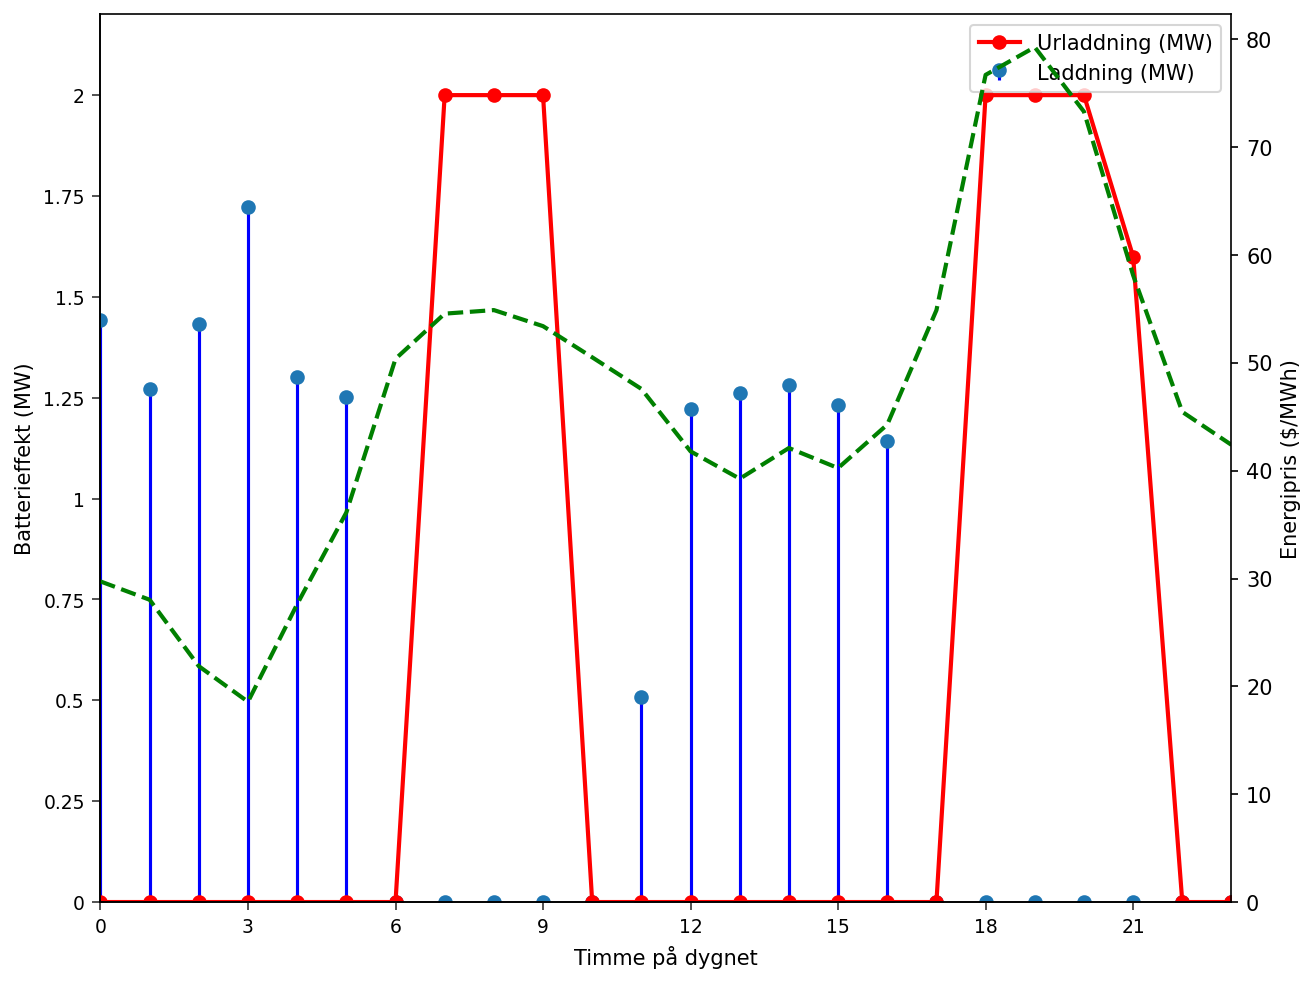

In [8]:
PROCEDUR SGPLOT data=dispatch;
    needle x=hour y=charge_mw / LINEATTRS=(color=blue thickness=3)
        legendlabel="Laddning (MW)";
    SERIES x=hour y=discharge_mw / LINEATTRS=(color=red thickness=2)
        MARKERS legendlabel="Urladdning (MW)";
    SERIES x=hour y=price / y2axis LINEATTRS=(color=green pattern=dash thickness=2)
        legendlabel="Pris ($/MWh)";
    XAXIS ETIKETT="Timme på dygnet" VALUES=(0 TILL 23 EFTER 3);
    YAXIS ETIKETT="Batterieffekt (MW)" MIN=0 MAX=2.2;
    y2axis ETIKETT="Energipris ($/MWh)" MIN=0;
KÖR;

## 9. Laddningsnivåns bana

Den lagrade energin stiger när batteriet fylls över natten, dras ned genom varje urladdningsfönster och överskrider aldrig taket för användbar kapacitet på 8 MWh (prickad referens).


NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


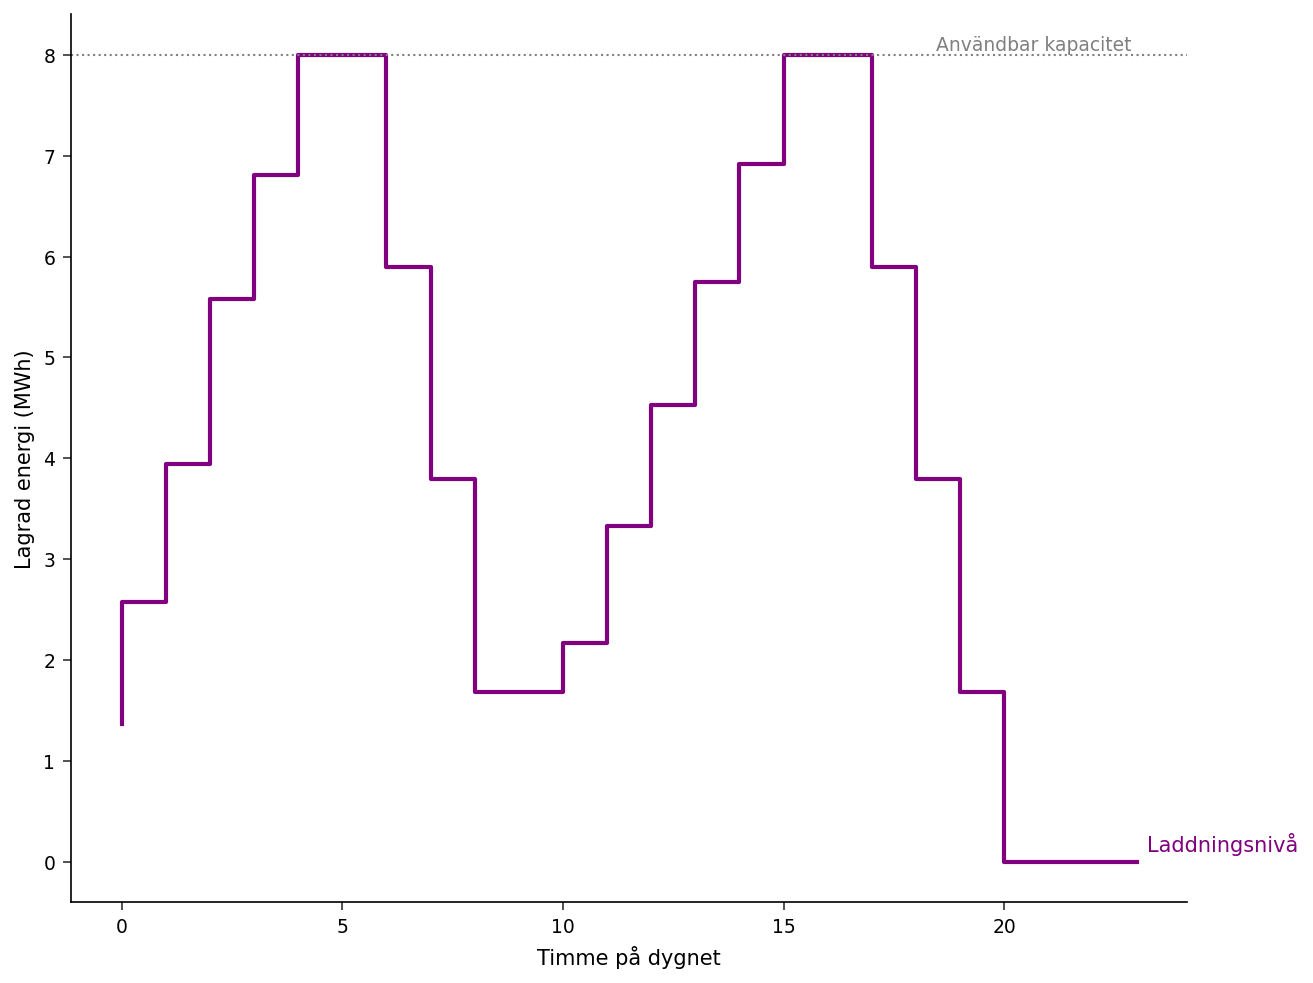

In [9]:
PROCEDUR SGPLOT data=dispatch;
    STEP x=hour y=soc_mwh / LINEATTRS=(color=purple thickness=2)
        curvelabel="Laddningsnivå";
    REFLINE 8 / AXIS=y LINEATTRS=(color=grey pattern=dot)
        ETIKETT="Användbar kapacitet";
    XAXIS ETIKETT="Timme på dygnet";
    YAXIS ETIKETT="Lagrad energi (MWh)";
KÖR;

## 10. Nätimport: före mot efter dispatch

Den orange linjen (nätimport med batteriet) faller väl under den streckade baslinjelasten genom kvällsuppgången (timmarna 18–21) — topputjämningseffekten som sänker effektavgiften. Under laddningsfönstren över natten och mitt på dagen stiger den, men optimeraren begränsar den till ett platt tak på ~3,43 MW som förblir *under* den ursprungliga lasttoppen på 3,59 MW, så att laddning köper billig energi utan att sätta ett nytt debiterat maximum.


NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


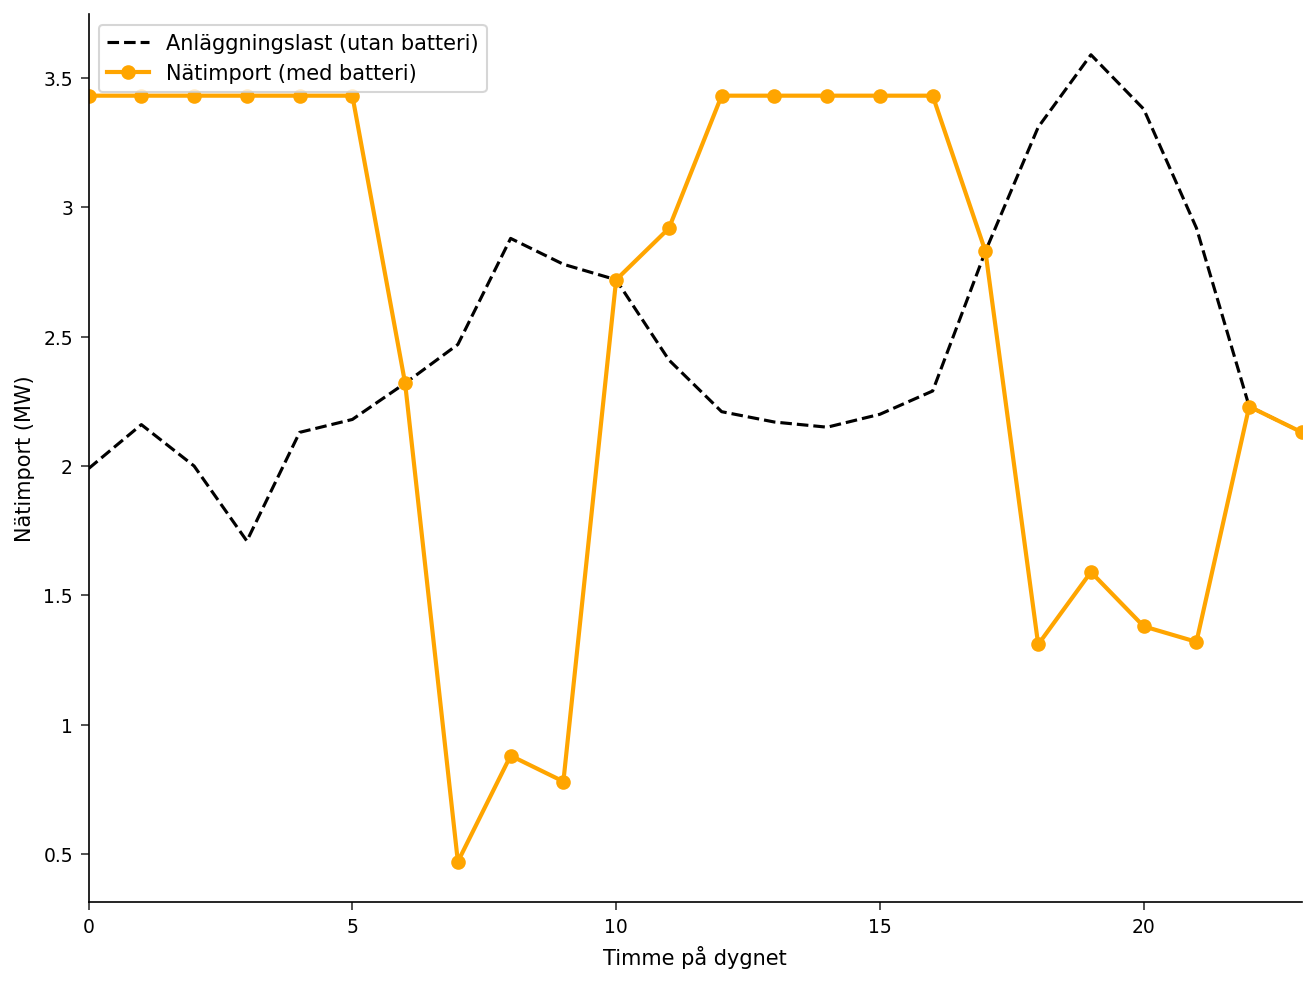

In [10]:
PROCEDUR SGPLOT data=dispatch;
    SERIES x=hour y=LOAD / LINEATTRS=(color=black pattern=dash)
        legendlabel="Anläggningslast (utan batteri)";
    SERIES x=hour y=grid_mw / LINEATTRS=(color=orange thickness=2)
        MARKERS legendlabel="Nätimport (med batteri)";
    XAXIS ETIKETT="Timme på dygnet";
    YAXIS ETIKETT="Nätimport (MW)";
KÖR;

## Tolkning och nästa steg

**Vad modellen beslutade.** Trots att rundtursverkningsgraden beskattar varje cykel fann optimeraren ändå tydligt värde: den fyllde batteriet under de billigaste nattimmarna, laddade ur in i morgonprisstoppen (timmarna 7–9), laddade om genom prisdalen mitt på dagen (timmarna 11–16) och laddade ur igen in i den rikaste kvällstoppen (timmarna 18–21). Talande nog laddade den vid endast 1,0–1,7 MW snarare än den fulla märkeffekten på 2 MW under nattfyllningen — och höll tillbaka effekten så att det ökade nätuttaget aldrig tryckte importen över dagens lasttopp. Laddningsnivån respekterade både kapaciteten på 8 MWh och effektgränsen på 2 MW hela tiden.

**Affärsnyttan.** Den dagliga energikostnaden föll från **\$2 903,78 till \$2 528,43** — **\$375,34 (12,9 %)** i arbitragebesparingar — och det debiterade nätmaximumet sjönk från **3,59 MW till 3,43 MW** (cirka **0,16 MW**), vilket skalade av ytterligare **\$18,98** från effektavgiftsraden. Årsberäknat över driftdagar plus den återkommande effektavgiftsminskningen är detta den typ av marginal som underbygger en lagringsinvestering.

**Varför ett LP är rätt verktyg.** Heuristiker ("ladda under medianpriset, ladda ur över") ignorerar verkningsgradsförluster, kapacitetskoppling över timmar och det faktum att effektavgiften beror på ett enda intervall — de skulle ladda vid full effekt över natten och *höja* den debiterade toppen, vilket förstör topputjämningsvärdet. PROC OPTMODEL fångar allt detta i en deklarativ modell och returnerar det bevisbart optimala schemat, som här avsiktligt modererar laddningstakten för att skydda toppen.

**Att utöka modellen.**

- **Längre horisonter / flera dagar** — utvidga indexmängden `HOURS`; lägg till gränser för cykling mellan dagar.
- **Prisosäkerhet** — lös LP:t över flera prisscenarier och medelvärdesbilda beslutet för första timmen (en rullande stokastisk policy).
- **Batteridegradering** — lägg till en genomströmningsstraffterm eller ett villkor på kumulativa cykler för att avväga arbitrage mot tillgångens livslängd.
- **Frekvensreglering / kapacitetsmarknader** — inför villkor för reserverad marginal så att batteriet kan stapla intäkter från stödtjänster ovanpå arbitrage.

Alla dessa är inkrementella ändringar av samma OPTMODEL-block — strukturen som etablerats här bär igenom oförändrad.